**A Machine Learning Approach for Mobile Money Loan Limit Prediction**

The project aims to develop a Mobile Money Credit Scoring System that analyzes a user’s past mobile money transaction history to determine the amount of money they are eligible to borrow, such as 2000 UGX. The system will first use clustering, an unsupervised machine learning technique, to group users into categories such as low-risk, medium-risk, and high-risk based on their transaction behavior, including transaction frequency, average transaction amount, account activity, and cash flow patterns. After grouping users, a predictive machine learning model using regression will estimate the exact loan amount a user qualifies for based on their historical financial behavior. To achieve this, transaction datasets from sources such as Kaggle will be collected and analyzed using tools like Pandas, Matplotlib, and Seaborn to extract important features including total transactions, average transaction value, monthly transaction volume, transaction consistency, and account age. The final system will include a user interface where a user’s name can be entered, and the system will automatically retrieve the user’s transaction history, analyze it, and display the eligible borrowing amount.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("assignment_dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<span style="color:red">Exploratory Data Analysis (EDA)</span>


**Univariate** analysis studies one variable at a time to understand its characteristics and distribution.

Histograms: Show how data values are distributed.

Box plots: Help detect outliers and show data spread.

Bar charts: Used for categorical variables

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df = df.drop('isFraud', axis=1)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [7]:
df = df.drop('isFlaggedFraud', axis=1)
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63


In [8]:
df.duplicated("nameOrig").sum()

np.int64(9313)

In [9]:
#values that appear more than one
counts = df['nameOrig'].value_counts()

print(counts[counts > 1])

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
              ..
C173838510     2
C603892473     2
C576310696     2
C369448390     2
C807221466     2
Name: count, Length: 9298, dtype: int64


In [10]:
#unique nameOrig entries in the entire DataFrame.
df.nameOrig.value_counts()

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
              ..
C1970706589    1
C40604503      1
C1614818636    1
C2089752665    1
C154988899     1
Name: count, Length: 6353307, dtype: int64

In [11]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


In [12]:
# visualizing feature distributions
import matplotlib.pyplot as plt
import seaborn as sns


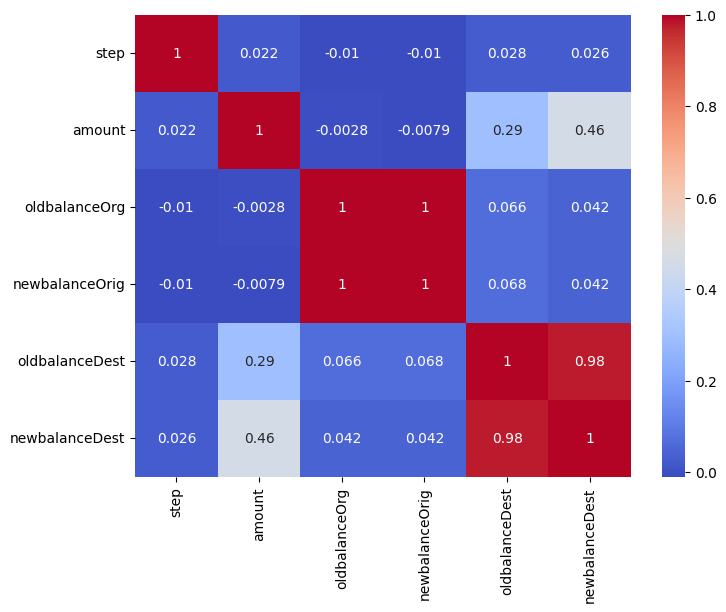

In [13]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

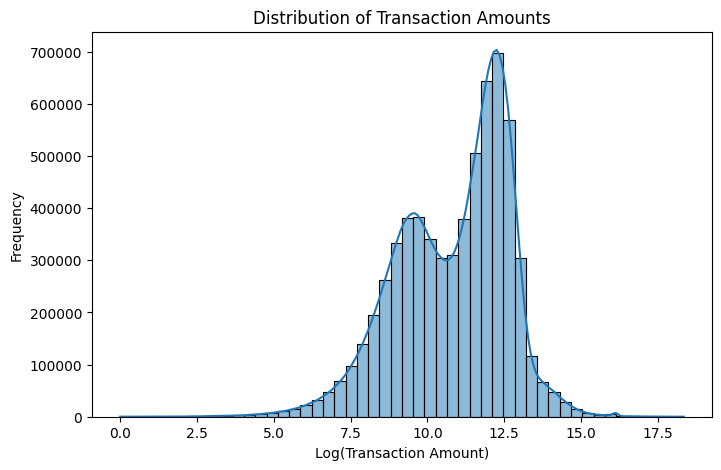

In [14]:
import seaborn as sns
import numpy as np 

plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['amount']), bins=50, kde=True)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Log(Transaction Amount)")
plt.ylabel("Frequency")

plt.show()

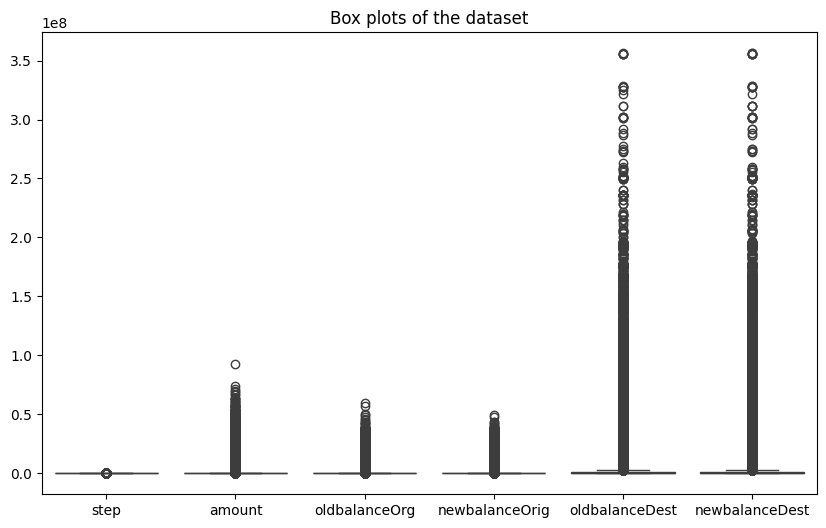

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



# Plotting
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop(columns=['nameOrig','nameDest']))
plt.title("Box plots of the dataset")
plt.show()

This indicates that while most users perform relatively small transactions and maintain low balances, a smaller group of users performs extremely 

large transactions or holds very high account balances